In [1]:
# for non-standard residues
from Bio.PDB.MMCIF2Dict import MMCIF2Dict

# cif to pdb, protein and ligands
from Bio.PDB import MMCIFParser, PDBIO, Select

# non-standard residue handling
from rdkit import Chem
from rdkit.Chem import AllChem

# to make water
from scipy.constants import N_A
from mendeleev import element

# general
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# OFF
from openff.toolkit import Molecule, Topology
from openff.units import unit as off_unit
from openff.toolkit import ForceField as OFF_ForceField
from openff.interchange import Interchange
from openff.interchange.components._packmol import pack_box

# https://docs.openforcefield.org/projects/toolkit/en/stable/api/generated/openff.toolkit.utils.toolkits.ToolkitRegistry.html
from openff.toolkit.utils import GLOBAL_TOOLKIT_REGISTRY, AmberToolsToolkitWrapper

# OMM
from openmm import LangevinIntegrator, Vec3
from openmm.app import Simulation, PDBReporter, StateDataReporter, PDBFile
from openmm.app import Modeller
from openmm.app import ForceField as OMM_ForceField
from openmm import unit as omm_unit

# warnings
import warnings
from rdkit import RDLogger
from openff.interchange.warnings import InterchangeCombinationWarning


# configs
RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=InterchangeCombinationWarning)  # trustmebro

packmol_dir = "/mnt/sds-hd/sd25g005/openmm/bin"
os.environ["PATH"] = os.pathsep.join([os.environ.get("PATH", ""), packmol_dir])

# AmberTools recognition
GLOBAL_TOOLKIT_REGISTRY.register_toolkit(AmberToolsToolkitWrapper())

# Inspiration
# https://pubs.acs.org/doi/10.1021/acs.jcim.1c00998
# https://docs.openforcefield.org/en/latest/examples/openforcefield/openff-interchange/protein_ligand/protein_ligand.html
# https://github.com/openforcefield/openff-interchange/blob/v0.5.2/examples/protein_ligand/protein_ligand.ipynb

In [2]:
# hide this away? or make it pretty?
import xml.etree.ElementTree as ET
import os

atom_types = set()
base = (
    "/mnt/sds-hd/sd25g005/openmm/lib/python3.12/site-packages/openmm/app/data/amber14"
)

residue_names = sorted(
    {
        res.attrib["name"]
        for f in glob.glob(os.path.join(base, "*.xml"))
        for res in ET.parse(f).getroot().findall(".//Residue")
    }
)

standard_aa_names = residue_names + ["HIS"]  # do not ask

## File Input

In [3]:
# not protonated, AF3 / Boltz output
input_file = "fold_2025_04_08_13_24_2insulin_model_0.cif"
basename = input_file.split(".")[0]

In [4]:
cif_dict = MMCIF2Dict(input_file)

ccd_ids = cif_dict["_chem_comp.id"]  # list of unique ids in cif
smiles = cif_dict["_chem_comp.pdbx_smiles"]  # list of unique smiles

nonstandard_dict = {
    rid: smiles[i] for i, rid in enumerate(ccd_ids) if rid not in standard_aa_names
}
nonstandard_dict

{}

In [5]:
if nonstandard_dict:
    nonstandard_residues = cif_dict["_pdbx_nonpoly_scheme.mon_id"]
    nonstandard_smiles = [nonstandard_dict[ccd] for ccd in nonstandard_residues]
    nonstandard_chains = cif_dict["_pdbx_nonpoly_scheme.pdb_strand_id"]
else:
    nonstandard_residues = []

## Split CIF File in protein.pdb and non-standard.sdf

In [6]:
# https://biopython.org/docs/dev/Tutorial/chapter_pdb.html#writing-pdb-files
parser = MMCIFParser()
structure = parser.get_structure("complex", input_file)

io = PDBIO()
io.set_structure(structure)


# does not work for glycosylation
class ProteinOnly(Select):
    def accept_residue(self, residue):
        return residue.get_resname() not in nonstandard_residues


io.save(f"{basename}_protein.pdb", ProteinOnly())

In [7]:
# this will most likely not work with glycosylation
# Select extension

# https://github.com/biopython/biopython/blob/master/Bio/PDB/PDBIO.py#L62
if nonstandard_residues:
    for chain, resname in zip(nonstandard_chains, nonstandard_residues):

        class Sel(Select):
            def accept_residue(self, residue, cn=chain, rn=resname):
                return residue.get_parent().id == cn and residue.get_resname() == rn

        io.save(f"{basename}_{chain}_{resname}.pdb", select=Sel())

In [8]:
# https://www.rdkit.org/docs/source/rdkit.Chem.rdmolfiles.html#rdkit.Chem.rdmolfiles.MolToMolFile
# this does not work for ions
if nonstandard_residues:
    for resname, smiles, chain in zip(
        nonstandard_residues, nonstandard_smiles, nonstandard_chains
    ):  # list
        pdb_mol = Chem.MolFromPDBFile(
            f"{basename}_{chain}_{resname}.pdb", removeHs=True
        )
        # use smiles as template where H have to go
        template = Chem.MolFromSmiles(smiles)
        mol = AllChem.AssignBondOrdersFromTemplate(template, pdb_mol)
        Chem.SanitizeMol(mol)
        mol = Chem.AddHs(mol, addCoords=True)
        Chem.MolToMolFile(mol, f"{basename}_{chain}_{resname}.sdf")

# Protein

In [9]:
pdb = PDBFile(f"{basename}_protein.pdb")
modeller = Modeller(pdb.topology, pdb.positions)

### Protein Forcefield (OMM)

In [11]:
forcefield = OMM_ForceField(  # should not need explicit paths, but does
    "/mnt/sds-hd/sd25g005/openmm/lib/python3.12/site-packages/openmm/app/data/amber14-all.xml",
    "/mnt/sds-hd/sd25g005/openmm/lib/python3.12/site-packages/openmm/app/data/tip3p.xml",
    "/mnt/sds-hd/sd25g005/openmm/lib/python3.12/site-packages/openforcefields/offxml/openff-2.2.0.offxml",
)

# https://docs.openmm.org/latest/api-python/generated/openmm.app.modeller.Modeller.html#openmm.app.modeller.Modeller.addHydrogens
modeller.addHydrogens(forcefield, pH=7)
# write tmp.pdb file
PDBFile.writeFile(
    modeller.topology, modeller.positions, open(f"{basename}_protein_H.pdb", "w")
)  # receptor only, with hydrogens, no water

In [12]:
# translate the Protein object from openMM to openFF
# requires Hydrogens
protein_with_crystal_water = Topology.from_pdb(f"{basename}_protein_H.pdb")

# splice out the protein(s) as a Molecule object
protein_molecules = [
    protein_with_crystal_water.molecule(n)
    for n in range(protein_with_crystal_water.n_molecules)
]

### Protein Forcefield (OFF)

In [13]:
# https://github.com/openforcefield/openff-interchange/blob/main/openff/interchange/components/interchange.py#L93
protein_interchange = Interchange.from_smirnoff(
    # impropers variant because Interchange doesn’t support Amber’s improper torsion function.
    force_field=OFF_ForceField("ff14sb_off_impropers_0.0.4.offxml"),
    # topology=protein.to_topology(),
    topology=protein_molecules,
)

# Ligand

In [14]:
# https://docs.openforcefield.org/projects/toolkit/en/stable/api/generated/openff.toolkit.topology.Molecule.html#openff.toolkit.topology.Molecule.from_file
# If there is a single molecule in the file, a Molecule is returned; otherwise, a list of Molecule objects is returned.
# We need single molecules for reasons

# this is dangerous for new users
files = sorted(glob.glob(f"{basename}_*.sdf"))
# molecules = [Molecule.from_file(f"{basename}_{resname}.sdf") for resname  in nonstandard_residues]
molecules = [Molecule.from_file(f) for f in files]

# one could do - but then positions glitch again
# https://docs.openforcefield.org/projects/toolkit/en/stable/api/generated/openff.toolkit.topology.Molecule.html#openff.toolkit.topology.Molecule.from_rdkit

In [15]:
if molecules:
    ligand_interchange = Interchange.from_smirnoff(
        force_field=OFF_ForceField(
            "openff_unconstrained-2.0.0.offxml"
        ),  # ligand force field
        topology=molecules,
    )

## Combine Protein and Ligand

In [16]:
if molecules:
    docked_interchange = protein_interchange.combine(ligand_interchange)
    docked_topology = Topology.from_molecules(protein_molecules + molecules)
else:
    docked_interchange = protein_interchange
    docked_topology = Topology.from_molecules(
        protein_molecules
    )  # check this for only protein

## Make the Simulation Box

In [17]:
# take entire solute into account
coords = [
    docked_topology.molecule(i).conformers[0]
    for i in range(docked_topology.n_molecules)
]
xyz = np.vstack(coords)

centroid = (
    xyz.sum(axis=0) / xyz.shape[0]
)  # unit of centroid is nm, but displayed as angstrom - do not be fooled

In [18]:
centered = xyz.to(off_unit.nanometer) - centroid
mins = centered[:, :3].magnitude.min(axis=0)
maxs = centered[:, :3].magnitude.max(axis=0)

padding = 2
aligned_box_vectors = np.diag(maxs - mins + padding) * off_unit.nanometer

volume = float(
    (aligned_box_vectors.diagonal().prod()).to(off_unit.centimeter**3).magnitude
)

### Fill with Water

In [19]:
# this assumes a rho of 1
mass_H2O = 2 * element("H").atomic_weight + element("O").atomic_weight

# number of TIP3P water molecules for a density of 1 g·cm⁻³
n_water = int(round(volume * N_A / mass_H2O))

### Add Ions

In [20]:
# did not include Na+, probably not ligand charge either
total_charge = round(sum(docked_interchange["Electrostatics"].charges.values()), 3)

In [21]:
# Define the solvent molecules and ions
solvent_mols = [Molecule.from_smiles(s) for s in ("O", "[Cl-]", "[Na+]")]

for mol in solvent_mols:
    mol.generate_conformers(n_conformers=1)

# Amount of copies of each solvent molecule
copies = [n_water, max(0, int(total_charge.m)), max(0, -int(total_charge.m))]

## Construct the Box


In [22]:
# topology of the solvent molecues
# https://github.com/openforcefield/openff-interchange/blob/main/openff/interchange/components/_packmol.py#L595

packed_topology = pack_box(
    molecules=solvent_mols,
    number_of_copies=copies,
    solute=docked_topology,
    box_vectors=aligned_box_vectors,
    center_solute=True,
)

packed_topology.to_file(f"{basename}_packed.pdb")

## Create Solvent Topology


In [23]:
water_interchange = Interchange.from_smirnoff(
    force_field=OFF_ForceField("openff_unconstrained-2.0.0.offxml"),
    topology=[solvent_mols[0]] * copies[0]
    + [solvent_mols[2]] * copies[2]
    + [solvent_mols[1]] * copies[1],
)

## Combine Solvent and Solute Topology

In [24]:
system_interchange = docked_interchange.combine(water_interchange)
# add positions back
system_interchange.positions = packed_topology.get_positions()
system_interchange.box = packed_topology.box_vectors

In [25]:
system_interchange

Interchange with 7 collections, periodic topology with 108870 atoms.

In [26]:
# export to openMM|
openmm_topology = system_interchange.topology.to_openmm(ensure_unique_atom_names=False)
openmm_system = system_interchange.to_openmm()

## Simulation Time!

In [27]:
integrator = LangevinIntegrator(
    300 * omm_unit.kelvin, 1 / omm_unit.picosecond, 0.002 * omm_unit.picoseconds
)
simulation = Simulation(openmm_topology, openmm_system, integrator)

### Update Positions

In [28]:
# https://docs.openmm.org/latest/api-python/generated/openmm.openmm.Context.html#openmm.openmm.Context.setPositions
pos_array = np.asarray(system_interchange.positions / omm_unit.nanometer, dtype=float)
vecs = [
    Vec3(float(x), float(y), float(z)) for x, y, z in pos_array
] * omm_unit.nanometer

simulation.context.setPositions(vecs)

In [29]:
simulation.minimizeEnergy()

In [30]:
log_file = f"{basename}_log.txt"
simulation.reporters.append(PDBReporter(f"{basename}_output.pdb", 100))
simulation.reporters.append(
    StateDataReporter(log_file, 100, step=True, potentialEnergy=True, temperature=True)
)

simulation.step(10000)

In [31]:
# Read OpenMM StateDataReporter log

df = pd.read_csv(log_file, header=0)
df.columns = [c.lstrip("#").strip('"') for c in df.columns]
df

,Step,Potential Energy (kJ/mole),Temperature (K)
0,100,-1.737824e+06,54.691628
1,200,-1.696348e+06,99.107739
2,300,-1.662081e+06,135.097415
3,400,-1.633352e+06,163.999011
4,500,-1.607704e+06,186.736146
...,...,...,...
95,9600,-1.442902e+06,301.059314
96,9700,-1.443648e+06,302.000043
97,9800,-1.442384e+06,300.638115
98,9900,-1.443119e+06,301.968218


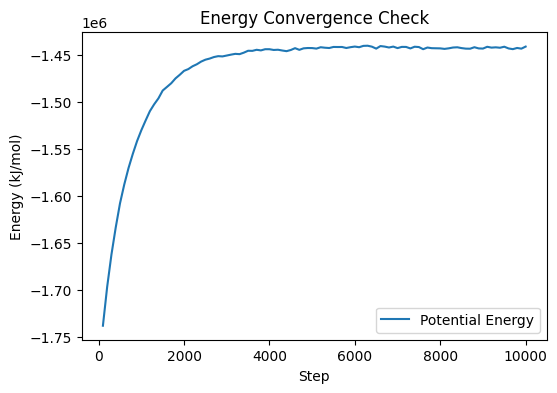

In [32]:
# Plot directly
plt.figure(figsize=(6, 4))
plt.plot(df["Step"], df["Potential Energy (kJ/mole)"], label="Potential Energy")
plt.xlabel("Step")
plt.ylabel("Energy (kJ/mol)")
plt.legend()
plt.title("Energy Convergence Check")
plt.show()